# Market & AI Pulse: Key Findings

**Sections:**
1. AI basket vs. S&P 500: full-period return
2. Does AI-sector search attention move before or after the stock moves?
3. AI basket trading-volume concentration
4. Sector return sensitivity to interest-rate moves
5. Realized volatility trend
6. Does AI infrastructure outperform the core basket?

Refreshes automatically every Monday as part of the pipeline. Each key finding above states how its headline number moved versus the prior week's run, tracked in `key_findings_history.json`. Still safe to re-run manually anytime (**Kernel → Restart & Run All**); a manual run adds its own entry to the history the same way.


## Setup

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone
from IPython.display import Markdown, display

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# --- config: adjust these to change the analysis without touching logic below ---
DATA_BASE_URL = 'https://pdglenchur-glitch.github.io/market_ai_pulse/data'
TOP_N_SPIKES = 5          # how many biggest attention spikes to event-study
EVENT_WINDOW_DAYS = 10    # trading days before/after each spike to measure
LAG_RANGE = range(-10, 11)  # lags (trading days) to test in the correlation scan

def fetch(table_name):
    url = f'{DATA_BASE_URL}/{table_name}.json'
    return pd.DataFrame(requests.get(url, timeout=30).json())

market = fetch('market_daily')
sector = fetch('sector_rotation')
ai_vs_market = fetch('ai_vs_market')
ai_basket_detail = fetch('ai_basket_detail')
attention = fetch('attention_index')
macro = fetch('macro_snapshot')
volatility = fetch('volatility')

print(f"Notebook run at: {datetime.now(timezone.utc).isoformat(timespec='seconds')}")
print(f"Latest market data date: {market['date'].max()}")
print(f"Latest attention data date: {attention['date'].max()}")
print(f"Trading days of AI-basket history: {ai_vs_market['ai_basket_return'].notna().sum()}")

Notebook run at: 2026-08-11T02:51:57+00:00
Latest market data date: 2026-08-07
Latest attention data date: 2026-08-09
Trading days of AI-basket history: 263


In [2]:
import json
from pathlib import Path

# History of week-over-week snapshots, one entry per run, written by the
# final cell of this notebook. Each finding below states how its headline
# number moved versus the last entry here.
HISTORY_PATH = Path('key_findings_history.json')
history = json.loads(HISTORY_PATH.read_text(encoding='utf-8')) if HISTORY_PATH.exists() else []
last_week = history[-1] if history else None
run_date = market['date'].max()
current_snapshot = {'date': run_date}

def describe_change(current, prev, prev_date, unit='pts', decimals=1):
    if prev is None:
        return "not yet trackable, this is the first tracked snapshot"
    delta = current - prev
    if round(delta, decimals) == 0:
        return f"flat versus last week's {prev:.{decimals}f}{unit} ({prev_date})"
    direction = "up" if delta > 0 else "down"
    return f"{direction} {abs(delta):.{decimals}f}{unit} versus last week's {prev:.{decimals}f}{unit} ({prev_date})"

if last_week is None:
    print("No prior weekly snapshot found. This run seeds the first tracked comparison point.")
else:
    print(f"Comparing against last tracked snapshot: {last_week['date']}")


Comparing against last tracked snapshot: 2026-08-07


## 1. AI basket vs. S&P 500

Compounds each series' daily return over the full available history to get a total cumulative return, then plots the two cumulative-return curves side by side.

In [3]:
avm = ai_vs_market.dropna(subset=['ai_basket_return', 'benchmark_return']).sort_values('date').reset_index(drop=True)

avm['ai_cum'] = (1 + avm['ai_basket_return']).cumprod() - 1
avm['bench_cum'] = (1 + avm['benchmark_return']).cumprod() - 1

ai_total = avm['ai_cum'].iloc[-1]
bench_total = avm['bench_cum'].iloc[-1]
spread = ai_total - bench_total

print(f"AI basket cumulative return:  {ai_total*100:+.2f}%")
print(f"S&P 500 cumulative return:    {bench_total*100:+.2f}%")
print(f"Spread:                       {spread*100:+.2f} points")
print(f"Window: {avm['date'].iloc[0]} -> {avm['date'].iloc[-1]}")

AI basket cumulative return:  +83.62%
S&P 500 cumulative return:    +22.95%
Spread:                       +60.67 points
Window: 2025-07-23 -> 2026-08-07


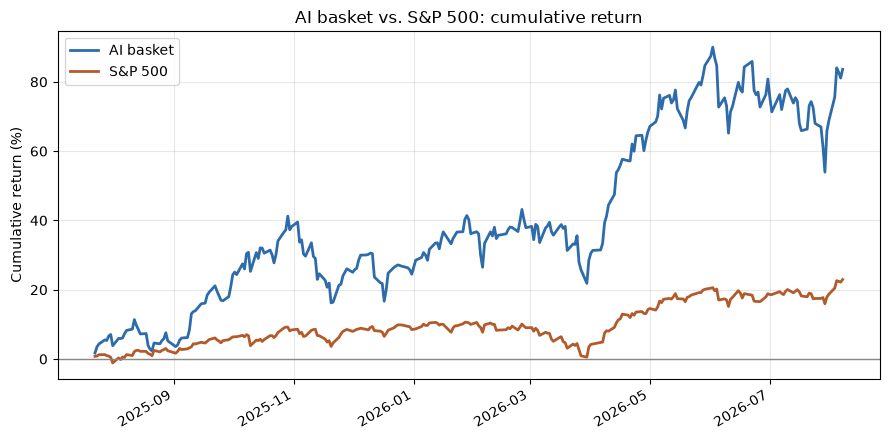

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
dates = pd.to_datetime(avm['date'])
ax.plot(dates, avm['ai_cum']*100, label='AI basket', color='#2d6bab', linewidth=2)
ax.plot(dates, avm['bench_cum']*100, label='S&P 500', color='#b35a2a', linewidth=2)
ax.axhline(0, color='#898781', linewidth=1)
ax.set_ylabel('Cumulative return (%)')
ax.set_title('AI basket vs. S&P 500: cumulative return')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [5]:
current_snapshot['section_1'] = {'ai_total_pct': float(ai_total * 100), 'bench_total_pct': float(bench_total * 100), 'spread_pts': float(spread * 100)}
prev_1 = last_week['section_1'] if last_week else None
spread_change = describe_change(spread * 100, prev_1['spread_pts'] if prev_1 else None, last_week['date'] if last_week else None)

direction = "outperformed" if spread > 0 else "underperformed"
magnitude = "a wide" if abs(spread * 100) >= 5 else "a narrow"

display(Markdown(
    f"**Key finding:** the AI basket has {direction} the S&P 500 by {magnitude} margin over this window, "
    f"{spread*100:+.1f} points ({ai_total*100:+.1f}% vs. {bench_total*100:+.1f}%). "
    + (
        "That gap is compounded over the full period rather than driven by any single volatile week, "
        "so it reads as a real, sustained premium for AI exposure."
        if spread > 0 else
        "The AI trade has given back its edge over the broader market during this window."
    )
    + f" The spread is {spread_change}."
))


**Key finding:** the AI basket has outperformed the S&P 500 by a wide margin over this window, +60.7 points (+83.6% vs. +22.9%). That gap is compounded over the full period rather than driven by any single volatile week, so it reads as a real, sustained premium for AI exposure. The spread is flat versus last week's 60.7pts (2026-08-07).

In [6]:
if spread > 0:
    insight_text = (
        "For an investor weighing whether to stay overweight AI relative to a broad index fund, this spread is the "
        "most direct evidence available that the position is still paying off. The action this supports is holding "
        "it while watching whether the spread keeps widening, which would say conviction is still building, or "
        "starts flattening, which would be the cue to trim back toward index weight before the premium erodes."
    )
else:
    insight_text = (
        "For an investor holding an AI overweight, this is the signal to reassess it. The extra return that would "
        "justify concentrating in AI names rather than simply holding the index isn't showing up over this window, "
        "so continuing to carry that overweight is a bet on the underlying growth story rather than on what the "
        "market is currently pricing in."
    )

display(Markdown(f"**Insight:** {insight_text}"))

**Insight:** For an investor weighing whether to stay overweight AI relative to a broad index fund, this spread is the most direct evidence available that the position is still paying off. The action this supports is holding it while watching whether the spread keeps widening, which would say conviction is still building, or starts flattening, which would be the cue to trim back toward index weight before the premium erodes.

## 2. Does AI-sector search attention move before or after the stock moves?

Public interest (Wikipedia pageviews on "Artificial intelligence," "ChatGPT," and "Large language model") is a plausible leading indicator for AI-stock sentiment, but it could just as easily be a lagging one (people search *because* a stock moved), or unrelated. This section tests it two ways rather than asserting an answer from a single observation.

In [7]:
attn = attention.groupby('date', as_index=False)['views'].sum().sort_values('date').reset_index(drop=True)
attn['views_pct_change'] = attn['views'].pct_change()

top_spikes = attn.dropna(subset=['views_pct_change']).nlargest(TOP_N_SPIKES, 'views_pct_change')
print(f"Top {TOP_N_SPIKES} single-day combined-attention spikes:")
top_spikes[['date', 'views', 'views_pct_change']].assign(
    views_pct_change=lambda d: (d['views_pct_change']*100).round(1)
)

Top 5 single-day combined-attention spikes:


,date,views,views_pct_change
251,2026-03-30,294984,251.80
364,2026-07-21,183346,171.30
119,2025-11-18,357396,114.40
219,2026-02-26,226717,77.40
91,2025-10-21,321071,62.70


### 2a. Day-to-day correlation across the full history

For each lag *k* (trading days), correlates today's attention change with the AI-basket return *k* days away. **k > 0** means attention today correlates with a *future* stock return (attention would be leading). **k < 0** means attention today correlates with a *past* stock return (stock moves would be leading, attention lagging).

In [8]:
merged = attn.merge(ai_vs_market[['date', 'ai_basket_return']], on='date', how='outer').sort_values('date').reset_index(drop=True)
attn_series = merged['views_pct_change'].to_numpy()
ret_series = merged['ai_basket_return'].to_numpy()
n = len(merged)

lag_results = []
for k in LAG_RANGE:
    xs, ys = [], []
    for i in range(n):
        j = i + k
        if 0 <= j < n and not np.isnan(attn_series[i]) and not np.isnan(ret_series[j]):
            xs.append(attn_series[i]); ys.append(ret_series[j])
    corr = np.corrcoef(xs, ys)[0, 1] if len(xs) >= 3 else np.nan
    lag_results.append({'lag': k, 'correlation': corr, 'n_pairs': len(xs)})

lag_df = pd.DataFrame(lag_results)
best = lag_df.loc[lag_df['correlation'].abs().idxmax()]
print(f"Strongest |correlation|: lag={int(best['lag'])}, r={best['correlation']:+.4f}, n={int(best['n_pairs'])}")
# rough 95% no-correlation threshold for reference, ~2/sqrt(n)
threshold = 2 / np.sqrt(lag_df['n_pairs'].mean())
print(f"Approx. 95% no-correlation threshold for this sample size: +/-{threshold:.3f}")
print(f"Note: {len(list(LAG_RANGE))} lags were tested, so a single lag crossing this threshold is expected by chance alone "
      "and is not strong evidence on its own.")
lag_df

Strongest |correlation|: lag=9, r=+0.1496, n=256
Approx. 95% no-correlation threshold for this sample size: +/-0.124
Note: 21 lags were tested, so a single lag crossing this threshold is expected by chance alone and is not strong evidence on its own.


,lag,correlation,n_pairs
0,-10,-0.11,257
1,-9,0.01,258
2,-8,0.02,258
3,-7,0.06,258
4,-6,-0.01,259
5,-5,-0.01,260
6,-4,-0.14,261
7,-3,-0.05,262
8,-2,0.03,263
9,-1,0.10,263


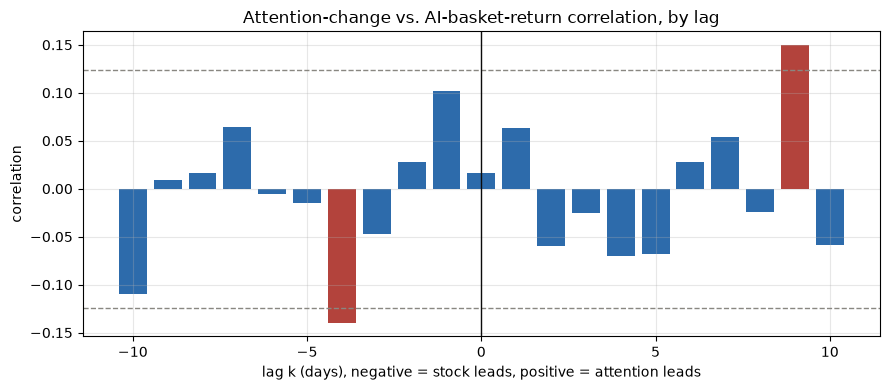

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#b3433c' if abs(c) >= threshold else '#2d6bab' for c in lag_df['correlation']]
ax.bar(lag_df['lag'], lag_df['correlation'], color=colors)
ax.axhline(threshold, color='#898781', linestyle='--', linewidth=1)
ax.axhline(-threshold, color='#898781', linestyle='--', linewidth=1)
ax.axvline(0, color='#0b0b0b', linewidth=1)
ax.set_xlabel('lag k (days), negative = stock leads, positive = attention leads')
ax.set_ylabel('correlation')
ax.set_title('Attention-change vs. AI-basket-return correlation, by lag')
plt.tight_layout()
plt.show()

**Reading this chart:** if attention genuinely led (or lagged) stock moves, we'd expect a cluster of bars on one side of zero to consistently clear the dashed threshold. What we actually see is scattered, roughly random-looking bars on both sides, consistent with noise rather than a real day-to-day relationship.

### 2b. Event study: the biggest attention spikes specifically

Routine day-to-day search chatter showed nothing above. A different, more targeted question: do the *few genuinely large* attention spikes behave differently than routine noise? Compares AI-basket cumulative return in the window before vs. after each of the top spikes.

In [10]:
dates_list = attn['date'].tolist()
date_idx = {d: i for i, d in enumerate(dates_list)}
ret_by_date = ai_vs_market.set_index('date')['ai_basket_return'].to_dict()

def window_return(center_date, start_offset, end_offset):
    ci = date_idx[center_date]
    cum, count = 1.0, 0
    for i in range(ci + start_offset, ci + end_offset + 1):
        if 0 <= i < len(dates_list):
            r = ret_by_date.get(dates_list[i])
            if r is not None and not (isinstance(r, float) and np.isnan(r)):
                cum *= (1 + r); count += 1
    return (cum - 1) * 100, count

event_rows = []
for _, row in top_spikes.iterrows():
    before, n_before = window_return(row['date'], -EVENT_WINDOW_DAYS, -1)
    after, n_after = window_return(row['date'], 1, EVENT_WINDOW_DAYS)
    event_rows.append({
        'spike_date': row['date'], 'spike_size_pct': row['views_pct_change'] * 100,
        'return_before_pct': before, 'n_before': n_before,
        'return_after_pct': after, 'n_after': n_after,
    })
event_df = pd.DataFrame(event_rows)
print(f"Average return before: {event_df['return_before_pct'].mean():+.2f}%")
print(f"Average return after:  {event_df['return_after_pct'].mean():+.2f}%")
event_df.round(2)

Average return before: -2.10%
Average return after:  +3.86%


,spike_date,spike_size_pct,return_before_pct,n_before,return_after_pct,n_after
0,2026-03-30,251.81,-9.02,6,15.93,7
1,2026-07-21,171.34,-6.52,6,-2.50,8
2,2025-11-18,114.44,-5.36,6,4.42,7
3,2026-02-26,77.41,5.50,7,-4.78,6
4,2025-10-21,62.66,4.90,6,6.24,8


**Honest conclusion:** the full-history correlation test found no reliable day-to-day lead-lag relationship: routine search-interest fluctuation doesn't predict or follow routine stock moves. The event study on the small number of genuinely large spikes shows a real gap (return-after minus return-before), but with only a handful of events this is suggestive at best rather than statistically reliable, and is worth re-checking every time this notebook is re-run as more spikes accumulate into the sample.

In [11]:
gap = event_df['return_after_pct'].mean() - event_df['return_before_pct'].mean()

current_snapshot['section_2'] = {
    'best_lag': int(best['lag']), 'best_corr': float(best['correlation']), 'gap_pts': float(gap),
    'return_before_pct': float(event_df['return_before_pct'].mean()), 'return_after_pct': float(event_df['return_after_pct'].mean()),
}
prev_2 = last_week['section_2'] if last_week else None
gap_change = describe_change(gap, prev_2['gap_pts'] if prev_2 else None, last_week['date'] if last_week else None)

display(Markdown(
    f"**Key finding:** across the {len(list(LAG_RANGE))} lags tested, the strongest single correlation was only "
    f"{best['correlation']:+.2f} (at a {int(best['lag'])}-day lag), too weak and too scattered across neighboring lags "
    f"to call a real day-to-day relationship. Around the {TOP_N_SPIKES} largest attention spikes specifically, "
    f"AI-basket returns averaged {event_df['return_before_pct'].mean():+.1f}% in the {EVENT_WINDOW_DAYS} trading days "
    f"before each spike versus {event_df['return_after_pct'].mean():+.1f}% after, a {gap:+.1f}-point swing. "
    f"With only {TOP_N_SPIKES} events behind it, that swing is a lead worth tracking rather than a signal to act on yet. "
    f"That swing is {gap_change}."
))


**Key finding:** across the 21 lags tested, the strongest single correlation was only +0.15 (at a 9-day lag), too weak and too scattered across neighboring lags to call a real day-to-day relationship. Around the 5 largest attention spikes specifically, AI-basket returns averaged -2.1% in the 10 trading days before each spike versus +3.9% after, a +6.0-point swing. With only 5 events behind it, that swing is a lead worth tracking rather than a signal to act on yet. That swing is flat versus last week's 6.0pts (2026-08-07).

In [12]:
display(Markdown(
    "**Insight:** A monitoring dashboard or trading signal built on routine day-to-day search interest would not "
    "have been reliable historically, so it isn't worth engineering that as a continuous input. The one place this "
    "data showed any pattern was around a handful of genuinely outsized spikes, which points to a narrower, cheaper "
    "use case: flag those rare spikes as a prompt to look closer, rather than feed the raw series into a model "
    "expecting it to predict returns day by day."
))

**Insight:** A monitoring dashboard or trading signal built on routine day-to-day search interest would not have been reliable historically, so it isn't worth engineering that as a continuous input. The one place this data showed any pattern was around a handful of genuinely outsized spikes, which points to a narrower, cheaper use case: flag those rare spikes as a prompt to look closer, rather than feed the raw series into a model expecting it to predict returns day by day.

## 3. AI basket trading-volume concentration

The dashboard's "AI basket" spans the AI value chain: chip design, the foundry and equipment behind it, AI memory, hyperscale cloud and neocloud compute, enterprise AI software, datacenter power (on-site and grid-scale), real estate, networking, and server/systems integration, plus a thematic ETF as a passive diversification check. Is trading activity actually spread across all of that, or still concentrated in one or two names?

In [13]:
vol_by_symbol = ai_basket_detail.dropna(subset=['volume']).groupby('symbol')['volume'].sum().sort_values(ascending=False)
vol_share = (vol_by_symbol / vol_by_symbol.sum() * 100).round(1)
print('Share of combined AI-basket trading volume:')
vol_share

Share of combined AI-basket trading volume:


symbol
NVDA    29.50
PLTR     8.80
AMZN     8.30
AMD      7.60
SMCI     6.50
MU       6.30
GOOGL    5.90
MSFT     5.40
CRWV     4.90
AVGO     4.40
META     2.80
TSM      2.30
BE       2.20
ANET     1.50
AMAT     1.40
VRT      1.20
CEG      0.50
DLR      0.40
BOTZ     0.10
Name: volume, dtype: float64

In [14]:
# Herfindahl-Hirschman Index (HHI): sum of squared percentage shares, 0 for
# a perfectly even split up to 10,000 for a single name. Standard bands:
# under 1,500 unconcentrated, 1,500-2,500 moderately concentrated, above
# 2,500 highly concentrated. Also compared against the original 7-name
# basket (before three expansions: to 11 names on 2026-07-28, to 17 on
# 2026-07-29, and to 19 on 2026-07-31), using the same volume data, to see
# whether adding names actually changed the concentration picture.
LEGACY_BASKET = ['NVDA', 'MSFT', 'GOOGL', 'META', 'PLTR', 'AMD', 'BOTZ']

def hhi(shares):
    return (shares ** 2).sum()

def concentration_band(h):
    if h > 2500:
        return "highly concentrated"
    if h > 1500:
        return "moderately concentrated"
    return "unconcentrated"

top_symbol, top_share = vol_share.index[0], vol_share.iloc[0]

current_hhi = hhi(vol_share)
current_effective_n = 10000 / current_hhi
current_band = concentration_band(current_hhi)

legacy_vol = ai_basket_detail[ai_basket_detail['symbol'].isin(LEGACY_BASKET)].dropna(subset=['volume'])
legacy_by_symbol = legacy_vol.groupby('symbol')['volume'].sum()
legacy_share = (legacy_by_symbol / legacy_by_symbol.sum() * 100).round(1)
legacy_hhi = hhi(legacy_share)
legacy_effective_n = 10000 / legacy_hhi
legacy_band = concentration_band(legacy_hhi)

fair_share = 100 / len(vol_share)
nvda_vs_fair = top_share / fair_share

print(f"Current basket ({len(vol_share)} names): HHI={current_hhi:.0f} ({current_band}), effective holdings={current_effective_n:.1f}")
print(f"Legacy basket ({len(LEGACY_BASKET)} names): HHI={legacy_hhi:.0f} ({legacy_band}), effective holdings={legacy_effective_n:.1f}")
print(f"{top_symbol} vs. equal-weight fair share ({fair_share:.1f}%): {nvda_vs_fair:.1f}x")

Current basket (19 names): HHI=1288 (unconcentrated), effective holdings=7.8
Legacy basket (7 names): HHI=2983 (highly concentrated), effective holdings=3.4
NVDA vs. equal-weight fair share (5.3%): 5.6x


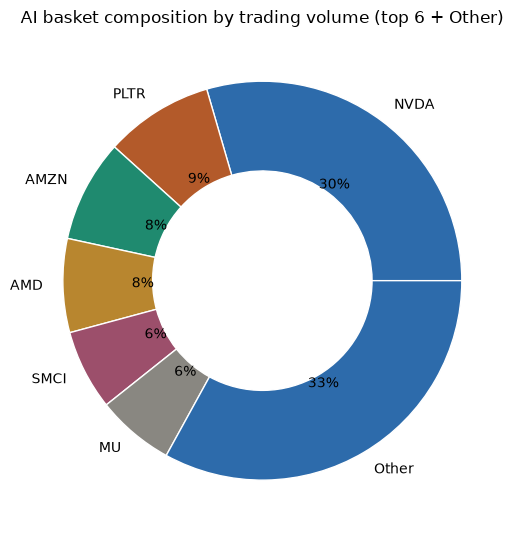

In [15]:
TOP_N_PIE = 6
pie_shares = vol_share.head(TOP_N_PIE).copy()
other_total = vol_share.iloc[TOP_N_PIE:].sum()
if other_total > 0:
    pie_shares['Other'] = round(other_total, 1)

palette = ['#2d6bab', '#b35a2a', '#1f8a6f', '#b8862f', '#9c4f6b', '#357a2b']
colors = palette[:len(pie_shares)]
if 'Other' in pie_shares.index:
    colors[-1] = '#898781'  # muted gray for Other, matches the live dashboard's donut

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.pie(pie_shares, labels=pie_shares.index, autopct='%1.0f%%', colors=colors,
       wedgeprops={'width': 0.45, 'edgecolor': 'white'})
ax.set_title('AI basket composition by trading volume (top 6 + Other)')
plt.tight_layout()
plt.show()

In [16]:
top_symbol, top_share = vol_share.index[0], vol_share.iloc[0]
second_symbol, second_share = vol_share.index[1], vol_share.iloc[1]
rest_share = 100 - top_share
scale_vs_second = top_share / second_share
basket_size = len(vol_share)

if top_share > rest_share:
    comparison = "more than the rest of the basket combined"
elif top_share >= rest_share * 0.8:
    comparison = f"nearly as much as the rest of the basket combined ({rest_share:.0f}%)"
else:
    comparison = f"a clear minority next to the other {basket_size - 1} names combined ({rest_share:.0f}%)"

current_snapshot['section_3'] = {
    'top_symbol': str(top_symbol), 'top_share_pct': float(top_share),
    'hhi': float(current_hhi), 'effective_n': float(current_effective_n),
}
prev_3 = last_week['section_3'] if last_week else None
share_change = describe_change(top_share, prev_3['top_share_pct'] if prev_3 else None, last_week['date'] if last_week else None, unit='%')

display(Markdown(
    f"**Key finding:** {top_symbol} accounts for {top_share:.0f}% of the AI basket's combined trading volume, "
    f"{comparison}, and {scale_vs_second:.1f}x {second_symbol}, the next-largest contributor at {second_share:.0f}%. "
    f"By the Herfindahl measure computed below, a basket spanning {basket_size} names is now {current_band} "
    f"overall, though {top_symbol} still stands well clear of every other single name. "
    f"{top_symbol}'s share is {share_change}."
))


**Key finding:** NVDA accounts for 30% of the AI basket's combined trading volume, a clear minority next to the other 18 names combined (70%), and 3.4x PLTR, the next-largest contributor at 9%. By the Herfindahl measure computed below, a basket spanning 19 names is now unconcentrated overall, though NVDA still stands well clear of every other single name. NVDA's share is flat versus last week's 29.5% (2026-08-07).

In [17]:
display(Markdown(
    f"**Insight:** Expanding the basket measurably reduced concentration. The Herfindahl index fell from "
    f"{legacy_hhi:.0f} ({legacy_band}, roughly {legacy_effective_n:.1f} effective holdings out of {len(LEGACY_BASKET)}) "
    f"to {current_hhi:.0f} ({current_band}, roughly {current_effective_n:.1f} effective holdings out of {len(vol_share)}). "
    f"{top_symbol} still sits well above an equal-weighted fair share, at {nvda_vs_fair:.1f}x, so it remains the single "
    f"name that matters most for basket-wide risk. Anyone using this basket as AI exposure should still treat "
    f"{top_symbol}-specific news, such as an earnings miss, a competitive threat, or a regulatory change, as a real "
    f"risk to the whole basket, even though it now carries less of that risk alone than it did before the expansion."
))

**Insight:** Expanding the basket measurably reduced concentration. The Herfindahl index fell from 2983 (highly concentrated, roughly 3.4 effective holdings out of 7) to 1288 (unconcentrated, roughly 7.8 effective holdings out of 19). NVDA still sits well above an equal-weighted fair share, at 5.6x, so it remains the single name that matters most for basket-wide risk. Anyone using this basket as AI exposure should still treat NVDA-specific news, such as an earnings miss, a competitive threat, or a regulatory change, as a real risk to the whole basket, even though it now carries less of that risk alone than it did before the expansion.

## 4. Sector return sensitivity to interest-rate moves

Splits trading days into "10Y yield rose" vs. "10Y yield fell," then compounds each sector's return within each group. Growth-tilted sectors are expected to underperform on rising-rate days; this checks whether that holds and whether any sector breaks the pattern.

In [18]:
yield_10y = macro[macro['series'] == '10y_yield'].sort_values('date').reset_index(drop=True)
yield_10y['direction'] = yield_10y['value'].diff().apply(lambda d: 'rising' if d > 0 else ('falling' if d < 0 else None))
direction_by_date = yield_10y.set_index('date')['direction'].to_dict()

sector_labeled = sector.dropna(subset=['daily_return']).copy()
sector_labeled['yield_direction'] = sector_labeled['date'].map(direction_by_date)
sector_labeled = sector_labeled.dropna(subset=['yield_direction'])

def compound(returns):
    return ((1 + returns).prod() - 1) * 100

rate_sensitivity = (
    sector_labeled.groupby(['symbol', 'yield_direction'])['daily_return']
    .apply(compound)
    .unstack('yield_direction')
    .round(2)
    .sort_values('rising')
)
rate_sensitivity

yield_direction,falling,rising
symbol,,
XLY,43.43,-35.49
XLB,55.64,-28.59
XLC,32.67,-26.88
XLRE,39.42,-22.39
XLI,50.17,-20.26
XLV,44.12,-12.82
XLU,23.57,-11.96
XLP,20.13,-11.05
XLK,34.73,-6.23


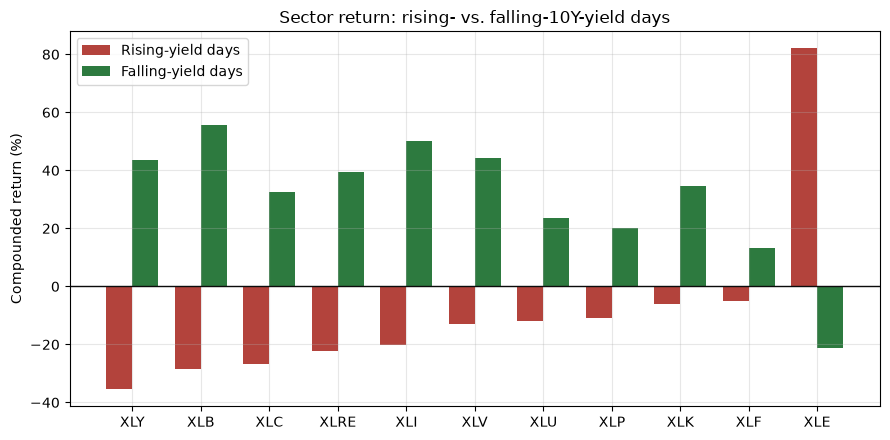

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(rate_sensitivity))
width = 0.38
ax.bar(x - width/2, rate_sensitivity['rising'], width, label='Rising-yield days', color='#b3433c')
ax.bar(x + width/2, rate_sensitivity['falling'], width, label='Falling-yield days', color='#2d7a3f')
ax.axhline(0, color='#0b0b0b', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(rate_sensitivity.index)
ax.set_ylabel('Compounded return (%)')
ax.set_title('Sector return: rising- vs. falling-10Y-yield days')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
exceptions = rate_sensitivity[rate_sensitivity['rising'] > rate_sensitivity['falling']]
typical_count = len(rate_sensitivity) - len(exceptions)

if len(exceptions) > 0:
    exc_names = ", ".join(exceptions.index)
    exception_line = (
        f"{exc_names} moved the opposite way, gaining rather than falling when yields rose, "
        f"a sector-specific story rather than a broad rate story."
    )
else:
    exception_line = "No sector broke the pattern over this window."

current_snapshot['section_4'] = {
    'typical_count': int(typical_count), 'total_sectors': int(len(rate_sensitivity)),
    'exceptions': list(exceptions.index),
}
prev_4 = last_week['section_4'] if last_week else None
count_change = describe_change(typical_count, prev_4['typical_count'] if prev_4 else None, last_week['date'] if last_week else None, unit=' sectors', decimals=0)

display(Markdown(
    f"**Key finding:** {typical_count} of {len(rate_sensitivity)} sectors followed the expected growth-sensitivity "
    f"pattern, falling on rising-yield days and rallying on falling-yield days. {exception_line} "
    f"The count following the pattern is {count_change}."
))


**Key finding:** 10 of 11 sectors followed the expected growth-sensitivity pattern, falling on rising-yield days and rallying on falling-yield days. XLE moved the opposite way, gaining rather than falling when yields rose, a sector-specific story rather than a broad rate story. The count following the pattern is flat versus last week's 10 sectors (2026-08-07).

In [21]:
if len(exceptions) > 0:
    insight_text = (
        f"This split is directly usable for positioning ahead of a known rate event such as an FOMC meeting: if "
        f"yields are expected to rise, the data supports rotating away from growth-tilted sectors and toward "
        f"{exc_names} specifically as a hedge, rather than moving to cash. It also doubles as an attribution check: "
        f"if a growth sector rallies on a day yields are rising, something sector-specific is driving it, worth "
        f"flagging rather than folding into the usual rate narrative."
    )
else:
    insight_text = (
        "This split is directly usable for positioning ahead of a known rate event such as an FOMC meeting: if "
        "yields are expected to rise, the data supports rotating away from growth-tilted sectors broadly, since no "
        "sector in this window offered a clean hedge against that move."
    )

display(Markdown(f"**Insight:** {insight_text}"))

**Insight:** This split is directly usable for positioning ahead of a known rate event such as an FOMC meeting: if yields are expected to rise, the data supports rotating away from growth-tilted sectors and toward XLE specifically as a hedge, rather than moving to cash. It also doubles as an attribution check: if a growth sector rallies on a day yields are rising, something sector-specific is driving it, worth flagging rather than folding into the usual rate narrative.

## 5. Realized volatility trend

Rolling 20-day realized volatility of the S&P 500 across the full history, with the highest- and lowest-volatility readings called out.

In [22]:
vol = volatility.dropna(subset=['rolling_20d_volatility']).sort_values('date').reset_index(drop=True)
vol_max = vol.loc[vol['rolling_20d_volatility'].idxmax()]
vol_min = vol.loc[vol['rolling_20d_volatility'].idxmin()]

print(f"Earliest reading: {vol['date'].iloc[0]}  {vol['rolling_20d_volatility'].iloc[0]*100:.2f}%")
print(f"Latest reading:   {vol['date'].iloc[-1]}  {vol['rolling_20d_volatility'].iloc[-1]*100:.2f}%")
print(f"Highest: {vol_max['date']}  {vol_max['rolling_20d_volatility']*100:.2f}%")
print(f"Lowest:  {vol_min['date']}  {vol_min['rolling_20d_volatility']*100:.2f}%")

Earliest reading: 2025-08-19  0.68%
Latest reading:   2026-08-07  0.91%
Highest: 2026-04-09  1.29%
Lowest:  2025-10-03  0.37%


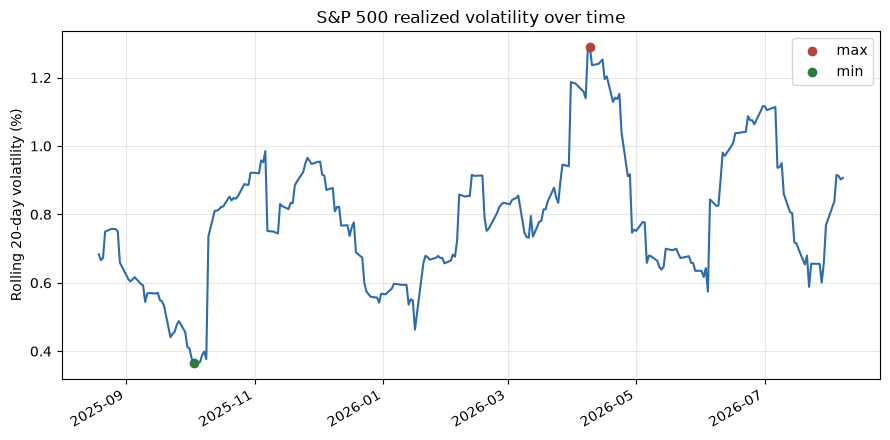

In [23]:
fig, ax = plt.subplots(figsize=(9, 4.5))
dates = pd.to_datetime(vol['date'])
ax.plot(dates, vol['rolling_20d_volatility']*100, color='#2d6bab', linewidth=1.5)
ax.scatter([pd.to_datetime(vol_max['date'])], [vol_max['rolling_20d_volatility']*100], color='#b3433c', zorder=5, label='max')
ax.scatter([pd.to_datetime(vol_min['date'])], [vol_min['rolling_20d_volatility']*100], color='#2d7a3f', zorder=5, label='min')
ax.set_ylabel('Rolling 20-day volatility (%)')
ax.set_title('S&P 500 realized volatility over time')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [24]:
avg_vol = vol['rolling_20d_volatility'].mean()
spike_ratio = vol_max['rolling_20d_volatility'] / avg_vol

current_snapshot['section_5'] = {
    'latest_vol_pct': float(vol['rolling_20d_volatility'].iloc[-1] * 100),
    'max_vol_pct': float(vol_max['rolling_20d_volatility'] * 100), 'max_date': str(vol_max['date']),
}
prev_5 = last_week['section_5'] if last_week else None
vol_change = describe_change(vol['rolling_20d_volatility'].iloc[-1] * 100, prev_5['latest_vol_pct'] if prev_5 else None, last_week['date'] if last_week else None, unit='%', decimals=2)

display(Markdown(
    f"**Key finding:** realized volatility peaked at {vol_max['rolling_20d_volatility']*100:.1f}% on {vol_max['date']}, "
    f"about {spike_ratio:.1f}x the {avg_vol*100:.2f}% trailing-window average, and has since eased back to "
    f"{vol['rolling_20d_volatility'].iloc[-1]*100:.2f}% as of the latest reading. That window is the clearest stress "
    f"signal in the data and the first place to look for a market-moving catalyst around {vol_max['date']}. "
    f"The latest reading is {vol_change}."
))


**Key finding:** realized volatility peaked at 1.3% on 2026-04-09, about 1.6x the 0.79% trailing-window average, and has since eased back to 0.91% as of the latest reading. That window is the clearest stress signal in the data and the first place to look for a market-moving catalyst around 2026-04-09. The latest reading is flat versus last week's 0.91% (2026-08-07).

In [25]:
display(Markdown(
    f"**Insight:** For a risk manager, the practical value here is the lead it gives for further investigation. "
    f"Cross-referencing {vol_max['date']} against news and earnings calendars turns 'volatility spiked' into a "
    f"specific cause, and knowing the cause is what determines whether it was a one-off shock or a recurring pattern, "
    f"such as an earnings season or a scheduled macro release, worth sizing positions around in advance next time."
))

**Insight:** For a risk manager, the practical value here is the lead it gives for further investigation. Cross-referencing 2026-04-09 against news and earnings calendars turns 'volatility spiked' into a specific cause, and knowing the cause is what determines whether it was a one-off shock or a recurring pattern, such as an earnings season or a scheduled macro release, worth sizing positions around in advance next time.

## 6. Does AI infrastructure outperform the core basket?

The basket was expanded in three steps: an original 9-name group (chip design, hyperscale cloud, AI software/capex, plus the thematic ETF), then 10 infrastructure names added across two later expansions to broaden coverage of the AI value chain (foundry, chip equipment, memory, neocloud compute, datacenter power, real estate, networking, and AI server/systems integration). Section 3 already showed the infrastructure names diluted concentration. This section asks a different question: did adding them also change the basket's return profile, not just its diversification profile?

In [26]:
# CORE_COHORT: the original 9 names present before any infrastructure-focused
# expansion (chip design, hyperscale cloud, AI software/capex, thematic ETF) -
# a different split than Section 3's LEGACY_BASKET, which is specifically the
# pre-expansion 7-name basket.
# INFRA_COHORT: every name added since, across two infrastructure-focused
# expansions - 2026-07-29 (TSM, AMAT, MU, VRT, DLR, BE, ANET, CRWV) and
# 2026-07-31 (CEG, SMCI) - spanning foundry, chip equipment, memory, neocloud
# compute, datacenter power (on-site and grid-scale), real estate,
# networking, and AI server/systems integration.
INFRA_COHORT = ['TSM', 'AMAT', 'MU', 'VRT', 'DLR', 'BE', 'ANET', 'CRWV', 'CEG', 'SMCI']
CORE_COHORT = ['NVDA', 'AMD', 'AVGO', 'MSFT', 'GOOGL', 'AMZN', 'META', 'PLTR', 'BOTZ']

def cohort_cumulative(symbols):
    sub = ai_basket_detail[ai_basket_detail['symbol'].isin(symbols)].dropna(subset=['daily_return'])
    daily = sub.groupby('date')['daily_return'].mean().sort_index()
    cum = (1 + daily).cumprod() - 1
    ann_vol = daily.std() * (252 ** 0.5)
    return daily, cum, ann_vol

def per_symbol_returns(symbols):
    out = {}
    for sym in symbols:
        sub = ai_basket_detail[ai_basket_detail['symbol'] == sym].dropna(subset=['daily_return']).sort_values('date')
        cum = (1 + sub['daily_return']).cumprod() - 1
        out[sym] = cum.iloc[-1] * 100
    return pd.Series(out).sort_values(ascending=False)

infra_daily, infra_cum, infra_ann_vol = cohort_cumulative(INFRA_COHORT)
core_daily, core_cum, core_ann_vol = cohort_cumulative(CORE_COHORT)
infra_final = infra_cum.iloc[-1] * 100
core_final = core_cum.iloc[-1] * 100

infra_returns = per_symbol_returns(INFRA_COHORT)
core_returns = per_symbol_returns(CORE_COHORT)

print(f"Infrastructure cohort ({len(INFRA_COHORT)} names): equal-weighted cumulative return {infra_final:+.1f}%, "
      f"median per-symbol {infra_returns.median():+.1f}%, annualized volatility {infra_ann_vol*100:.1f}%")
print(f"Core cohort ({len(CORE_COHORT)} names): equal-weighted cumulative return {core_final:+.1f}%, "
      f"median per-symbol {core_returns.median():+.1f}%, annualized volatility {core_ann_vol*100:.1f}%")
print()
print("Infrastructure cohort, per symbol:")
print(infra_returns.round(1))
print()
print("Core cohort, per symbol:")
print(core_returns.round(1))

Infrastructure cohort (10 names): equal-weighted cumulative return +120.4%, median per-symbol +76.4%, annualized volatility 46.8%
Core cohort (9 names): equal-weighted cumulative return +45.3%, median per-symbol +20.7%, annualized volatility 26.6%

Infrastructure cohort, per symbol:
BE     745.90
MU     704.80
AMAT   190.20
VRT    117.70
TSM     81.00
ANET    71.90
DLR     11.20
CEG    -14.60
CRWV   -30.10
SMCI   -37.60
dtype: float64

Core cohort, per symbol:
AMD     212.40
GOOGL    85.70
AVGO     54.70
NVDA     34.30
AMZN     20.70
PLTR     15.40
BOTZ     14.90
MSFT     -0.30
META    -15.70
dtype: float64


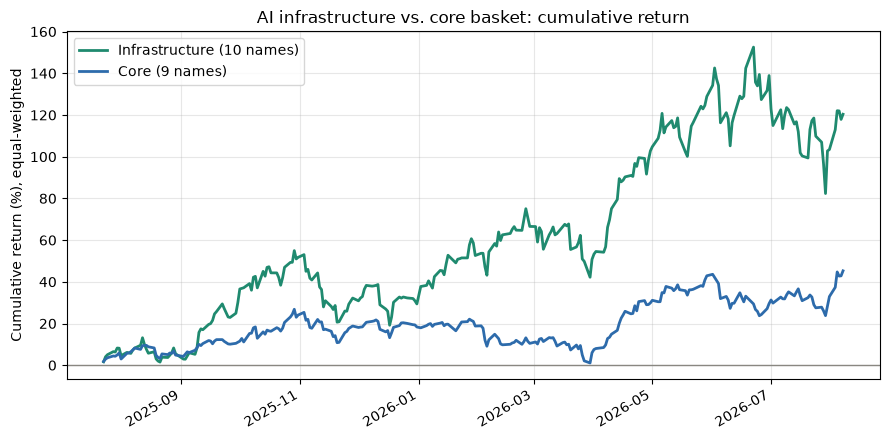

In [27]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(pd.to_datetime(infra_cum.index), infra_cum * 100, label=f'Infrastructure ({len(INFRA_COHORT)} names)', color='#1f8a6f', linewidth=2)
ax.plot(pd.to_datetime(core_cum.index), core_cum * 100, label=f'Core ({len(CORE_COHORT)} names)', color='#2d6bab', linewidth=2)
ax.axhline(0, color='#898781', linewidth=1)
ax.set_ylabel('Cumulative return (%), equal-weighted')
ax.set_title('AI infrastructure vs. core basket: cumulative return')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [28]:
gap_infra_core = infra_final - core_final
worst_infra_symbol, worst_infra_return = infra_returns.index[-1], infra_returns.iloc[-1]
n_infra_negative = int((infra_returns < 0).sum())

current_snapshot['section_6'] = {
    'infra_final_pct': float(infra_final), 'core_final_pct': float(core_final),
    'gap_pts': float(gap_infra_core), 'n_infra_negative': int(n_infra_negative),
}
prev_6 = last_week['section_6'] if last_week else None
gap6_change = describe_change(gap_infra_core, prev_6['gap_pts'] if prev_6 else None, last_week['date'] if last_week else None)

display(Markdown(
    f"**Key finding:** the infrastructure cohort ({len(INFRA_COHORT)} names spanning foundry, chip equipment, "
    f"memory, neocloud compute, datacenter power, real estate, networking, and server integration) returned "
    f"{infra_final:+.1f}% on an equal-weighted basis versus {core_final:+.1f}% for the original core cohort, a "
    f"{gap_infra_core:+.1f}-point gap. This isn't one or two names skewing an average: the median individual "
    f"infrastructure name returned {infra_returns.median():+.1f}%, well above the median core name's "
    f"{core_returns.median():+.1f}%. The gap comes with a real cost, though. Infrastructure names carried "
    f"{infra_ann_vol*100:.0f}% annualized volatility against {core_ann_vol*100:.0f}% for the core cohort, and "
    f"{n_infra_negative} of {len(INFRA_COHORT)} infrastructure names are actually down over the same window "
    f"({worst_infra_symbol} the worst, at {abs(worst_infra_return):.0f}%), a reminder that 'infrastructure' "
    f"hasn't been a uniformly winning trade even as the cohort overall has done well. "
    f"The infra-versus-core gap is {gap6_change}."
))


**Key finding:** the infrastructure cohort (10 names spanning foundry, chip equipment, memory, neocloud compute, datacenter power, real estate, networking, and server integration) returned +120.4% on an equal-weighted basis versus +45.3% for the original core cohort, a +75.1-point gap. This isn't one or two names skewing an average: the median individual infrastructure name returned +76.4%, well above the median core name's +20.7%. The gap comes with a real cost, though. Infrastructure names carried 47% annualized volatility against 27% for the core cohort, and 3 of 10 infrastructure names are actually down over the same window (SMCI the worst, at 38%), a reminder that 'infrastructure' hasn't been a uniformly winning trade even as the cohort overall has done well. The infra-versus-core gap is flat versus last week's 75.1pts (2026-08-07).

In [29]:
vol_ratio = infra_ann_vol / core_ann_vol
negative_infra_names = ", ".join(infra_returns[infra_returns < 0].index)

display(Markdown(
    f"**Insight:** For someone deciding how much of an AI allocation to put toward infrastructure names rather "
    f"than the established chip-and-cloud names, the return case is real but so is the volatility trade-off: the "
    f"infrastructure cohort delivered roughly {gap_infra_core:.0f} points more return at {vol_ratio:.1f}x the "
    f"annualized volatility of the core cohort. That argues for sizing an infrastructure allocation deliberately, "
    f"rather than assuming more names automatically means more diversification benefit with no added risk. "
    f"{negative_infra_names} are the concrete case studies here: even within a theme that outperformed broadly, "
    f"single-name selection inside it still mattered, and picking the theme alone wasn't enough to guarantee a "
    f"winning position in every name that theme touches."
))

**Insight:** For someone deciding how much of an AI allocation to put toward infrastructure names rather than the established chip-and-cloud names, the return case is real but so is the volatility trade-off: the infrastructure cohort delivered roughly 75 points more return at 1.8x the annualized volatility of the core cohort. That argues for sizing an infrastructure allocation deliberately, rather than assuming more names automatically means more diversification benefit with no added risk. CEG, CRWV, SMCI are the concrete case studies here: even within a theme that outperformed broadly, single-name selection inside it still mattered, and picking the theme alone wasn't enough to guarantee a winning position in every name that theme touches.

In [30]:
history.append(current_snapshot)
HISTORY_PATH.write_text(json.dumps(history, indent=2, default=str), encoding='utf-8')
print(f"Saved snapshot for {current_snapshot['date']} to {HISTORY_PATH} ({len(history)} snapshot(s) on record).")


Saved snapshot for 2026-08-07 to key_findings_history.json (2 snapshot(s) on record).


## Summary

| # | Finding | Confidence |
|---|---|---|
| 1 | AI basket outperformed the S&P 500 over the full period | High: direct calculation |
| 2 | Attention spikes vs. stock moves | Mixed: no day-to-day relationship; a suggestive but small-sample pattern around the biggest spikes only |
| 3 | NVDA remains the largest single contributor to basket trading volume by a wide margin, even as overall basket concentration has eased with each expansion | High: direct calculation |
| 4 | Growth sectors underperform on rising-yield days, Energy is the exception | High: consistent with known rate-sensitivity dynamics |
| 5 | Volatility had one clear outlier window | High: direct calculation |
| 6 | The infrastructure names added since the original basket outperformed the core cohort on average, at meaningfully higher volatility and with real single-name exceptions | High: direct calculation, broad across names rather than outlier-driven |

This notebook refreshes automatically every Monday as part of the pipeline, and each finding above states how it moved versus the prior week (`analysis/key_findings_history.json` holds the full trail). It's still safe to re-run manually anytime (`Kernel -> Restart & Run All`) to refresh against whatever's live at that moment. Section 2 in particular is worth watching over time: the event-study sample grows with every new attention spike, so its conclusion may firm up or fall apart as more data arrives.